In [67]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
date = pd.Timestamp("2023-10-01")
date

Timestamp('2023-10-01 00:00:00')

In [13]:
date - pd.DateOffset(days=date.day - 1) - pd.DateOffset(months=(date.month-1)%3)

Timestamp('2023-10-01 00:00:00')

In [152]:
def readfile(filename):
    df = pd.read_csv(filename, parse_dates=["date"])
    
    # Use date as index, sorting
    df.set_index("date", inplace=True)
    df.sort_index(inplace=True)
    
    # Drop older years
    df = df[df.index.year==2023]
    
    # Get the number of regressions introduced in each test run
    df["regressions_change"] = df["num_regressions"].diff(periods=1)
    df["num_total"] = df["num_passes"] + df["num_regressions"] + df["num_flaky"]
    return df

wpe_release_df = readfile("../WPE-Release.csv")
wpe_debug_df = readfile("../WPE-Debug.csv")
gtk_release_df = readfile("../GTK-Release.csv")
gtk_debug_df = readfile("../GTK-Debug.csv")

In [106]:
def largest_regressions(df, n=10):
    return df.nlargest(n, ["regressions_change"])

In [107]:
largest_regressions(wpe_release_df, n=20)

,uses_expectations_file,num_regressions,has_pretty_patch,other_crashes,num_passes,revision,layout_tests_dir,version,skipped,num_missing,num_flaky,fixable,pixel_tests_enabled,interrupted,regressions_change
date,,,,,,,,,,,,,,,
2017-09-06 08:26:00,True,500,True,{},1547,193031@main,/home/buildbot/wpe/wpe-linux-64-release-tests/...,4,47270,0,0,47817,False,True,496.0
2017-09-12 05:00:00,True,500,True,{},6349,193250@main,/home/buildbot/wpe/wpe-linux-64-release-tests/...,4,42428,0,0,43029,False,True,493.0
2017-09-15 00:24:00,True,500,True,{},6617,193399@main,/home/buildbot/wpe/wpe-linux-64-release-tests/...,4,42180,0,0,42787,False,True,493.0
2020-09-23 16:33:00,True,500,True,{},35526,229688@main,/app/webkit/LayoutTests,4,27810,0,0,31114,False,True,492.0
2020-06-03 20:06:00,True,500,True,{},31835,225547@main,/app/webkit/LayoutTests,4,28526,0,0,31197,False,True,475.0
2021-05-15 22:17:00,True,500,True,{},31524,237791@main,/app/webkit/LayoutTests,4,36417,0,0,39474,False,True,474.0
2020-03-27 16:05:00,True,484,True,{},39056,222608@main,/home/buildbot/wpe/wpe-linux-64-release-tests/...,4,21762,16,0,24338,False,True,466.0
2023-08-19 00:13:00,True,500,True,{},21185,267068@main,/app/webkit/LayoutTests,4,63708,0,0,65371,False,True,455.0
2023-08-07 11:32:00,True,500,True,{},21194,266642@main,/app/webkit/LayoutTests,4,63160,0,0,64828,False,True,454.0


In [96]:
largest_regressions(gtk_release_df, n=20)

,num_regressions,num_passes,uses_expectations_file,interrupted,layout_tests_dir,pixel_tests_enabled,num_flaky,has_pretty_patch,num_missing,fixable,skipped,version,revision,other_crashes,regressions_change
date,,,,,,,,,,,,,,,
2022-06-08 23:56:00,500,25508,True,True,/app/webkit/LayoutTests,False,0,True,0,51282,49473,4,251416@main,{},452.0
2022-08-04 11:04:00,500,25849,True,True,/app/webkit/LayoutTests,False,0,True,0,52045,50245,4,253119@main,{},434.0
2023-08-15 02:19:00,500,25303,True,True,/app/webkit/LayoutTests,False,0,True,0,61138,59287,4,266899@main,{},348.0
2023-08-27 19:53:00,500,25233,True,True,/app/webkit/LayoutTests,False,0,True,0,61333,59482,4,267338@main,{},339.0
2023-05-15 20:45:00,499,55462,True,True,/app/webkit/LayoutTests,False,0,True,1,29160,24296,4,264096@main,{},303.0
2023-02-03 16:48:00,499,47553,True,True,/app/webkit/LayoutTests,False,0,True,1,36054,31710,4,259831@main,{},297.0
2023-02-16 06:39:00,499,57509,True,True,/app/webkit/LayoutTests,False,0,True,1,26244,21415,4,260361@main,{},278.0
2023-02-10 23:56:00,499,60635,True,True,/app/webkit/LayoutTests,False,0,True,1,23109,18184,4,260145@main,{},275.0
2023-01-29 21:03:00,500,65560,True,True,/app/webkit/LayoutTests,False,0,True,0,17345,12298,4,259541@main,{},273.0


In [109]:
wpe_release_df['interrupted'].mean()

0.1095928015860912

In [139]:
def chart_completeness(df, label):
    monthly_percentage_interrupted = df['interrupted'].resample('W').mean() * 100
    print(monthly_percentage_interrupted)
    monthly_percentage_not_interrupted = df['interrupted'].eq(False).resample('W').mean() * 100
    plt.figure(figsize=(10, 6))
    monthly_percentage_interrupted.plot(marker='o', linestyle='-', color='r', label='Interrupted')
    monthly_percentage_not_interrupted.plot(marker='o', linestyle='-', color='b', label='Complete')
    plt.xlabel('Month')
    plt.ylabel('Percentage of runs')
    plt.title(f'{label} - Monthly Percentage of Complete vs Incomplete runs')
    plt.legend()
    plt.grid(True)

date
2023-01-08      0.000000
2023-01-15      0.000000
2023-01-22      7.894737
2023-01-29     72.093023
2023-02-05     70.707071
2023-02-12     52.941176
2023-02-19      0.000000
2023-02-26      0.000000
2023-03-05     50.000000
2023-03-12      0.000000
2023-03-19      0.000000
2023-03-26      0.000000
2023-04-02      0.000000
2023-04-09      0.000000
2023-04-16      0.000000
2023-04-23     62.096774
2023-04-30     25.773196
2023-05-07     40.206186
2023-05-14     50.505051
2023-05-21     25.000000
2023-05-28     16.867470
2023-06-04      0.000000
2023-06-11      0.000000
2023-06-18      0.000000
2023-06-25      0.000000
2023-07-02     20.731707
2023-07-09      0.000000
2023-07-16     22.222222
2023-07-23    100.000000
2023-07-30    100.000000
2023-08-06     47.222222
2023-08-13      1.149425
2023-08-20      1.111111
2023-08-27      0.000000
2023-09-03      0.000000
2023-09-10      0.000000
2023-09-17     21.359223
2023-09-24      8.256881
2023-10-01      0.000000
2023-10-08      0.00

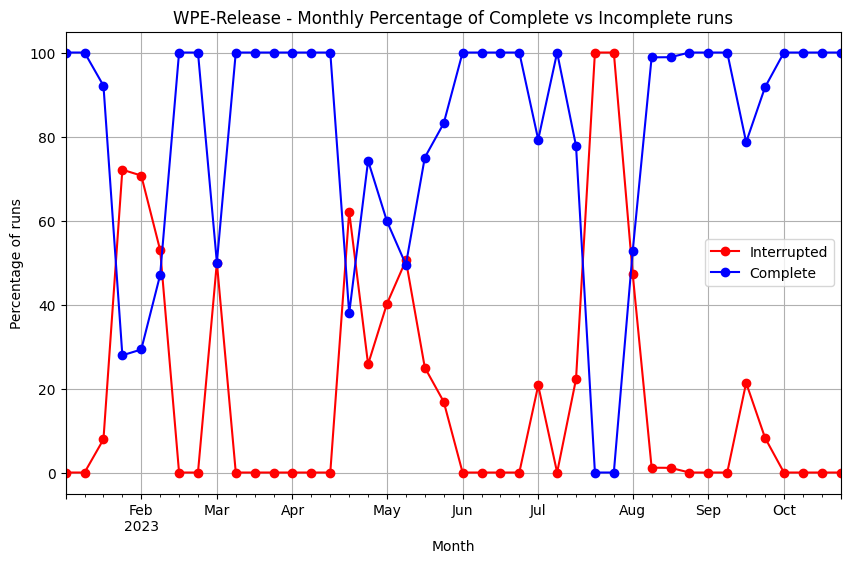

In [140]:
chart_completeness(wpe_release_df, 'WPE-Release')

date
2016-01-31    17.901235
2016-02-29     4.231975
2016-03-31    25.541126
2016-04-30     0.156740
2016-05-31     4.045307
                ...    
2023-06-30    55.172414
2023-07-31    76.833977
2023-08-31     0.816327
2023-09-30    10.943396
2023-10-31     0.000000
Freq: M, Name: interrupted, Length: 94, dtype: float64


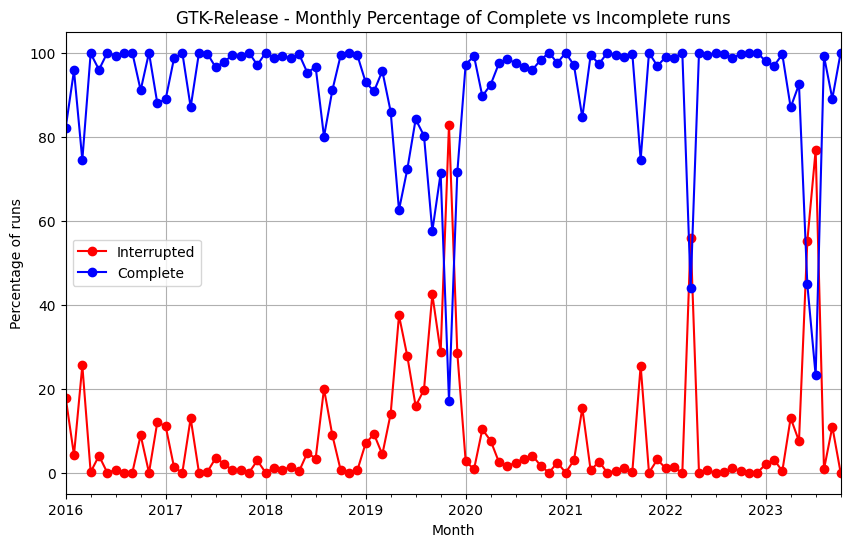

In [111]:
chart_completeness(gtk_release_df, 'GTK-Release')

date
2018-04-30     25.581395
2018-05-31     57.276995
2018-06-30     23.696682
2018-07-31      0.892857
2018-08-31      0.847458
                 ...    
2023-06-30    100.000000
2023-07-31    100.000000
2023-08-31    100.000000
2023-09-30    100.000000
2023-10-31    100.000000
Freq: M, Name: interrupted, Length: 67, dtype: float64


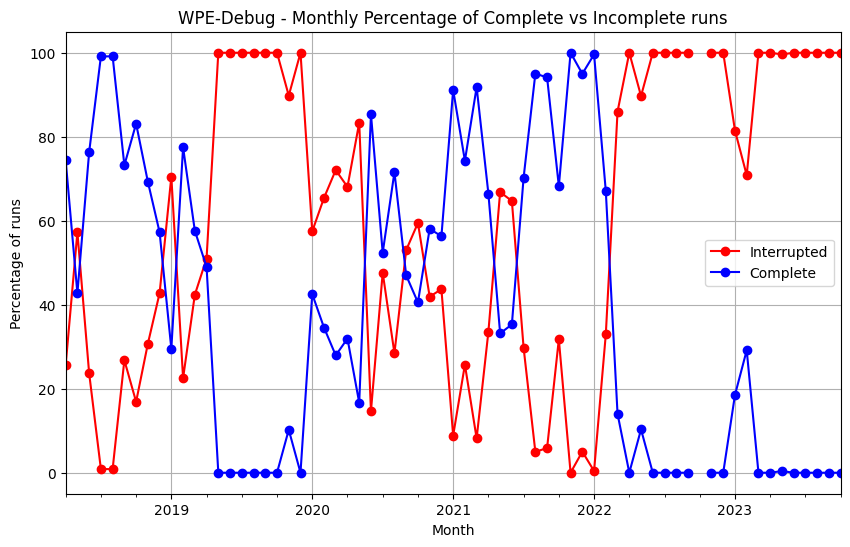

In [112]:
chart_completeness(wpe_debug_df, 'WPE-Debug')

date
2017-05-31    100.000000
2017-06-30     58.064516
2017-07-31     10.055866
2017-08-31      9.677419
2017-09-30      7.017544
                 ...    
2023-06-30           NaN
2023-07-31    100.000000
2023-08-31    100.000000
2023-09-30    100.000000
2023-10-31    100.000000
Freq: M, Name: interrupted, Length: 78, dtype: float64


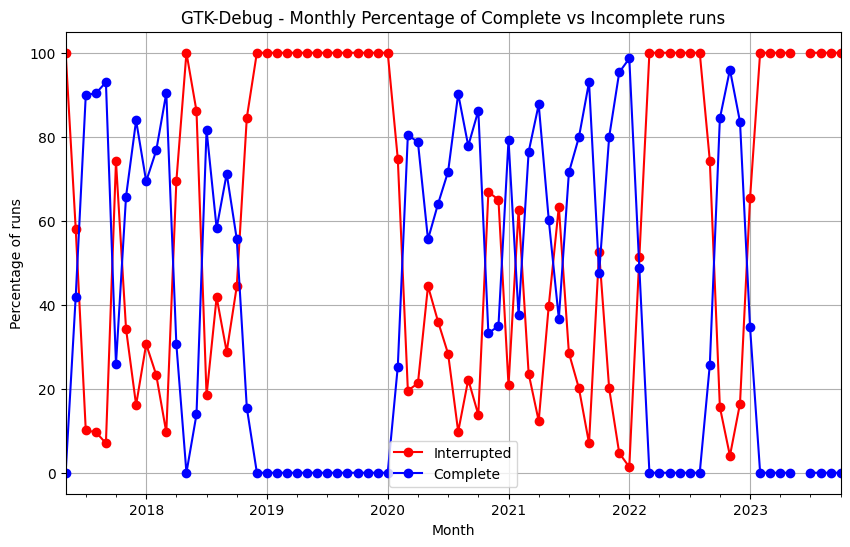

In [113]:
chart_completeness(gtk_debug_df, 'GTK-Debug')

In [151]:
def chart_regressions_flakies(df, label):
    average_weekly_regressions = df['num_regressions'].resample('W').mean()
    average_weekly_flakies = df['num_flaky'].resample('W').mean()
    plt.figure(figsize=(10, 6))
    average_weekly_flakies.plot(marker='o', linestyle='-', color='r', label='Flakies')
    average_weekly_regressions.plot(marker='o', linestyle='-', color='b', label='Regressions')
    plt.xlabel('Date')
    plt.ylabel('Monthly average')
    plt.title(f'{label} - Monthly Percentage of Complete vs Incomplete runs')
    plt.legend()
    plt.grid(True)

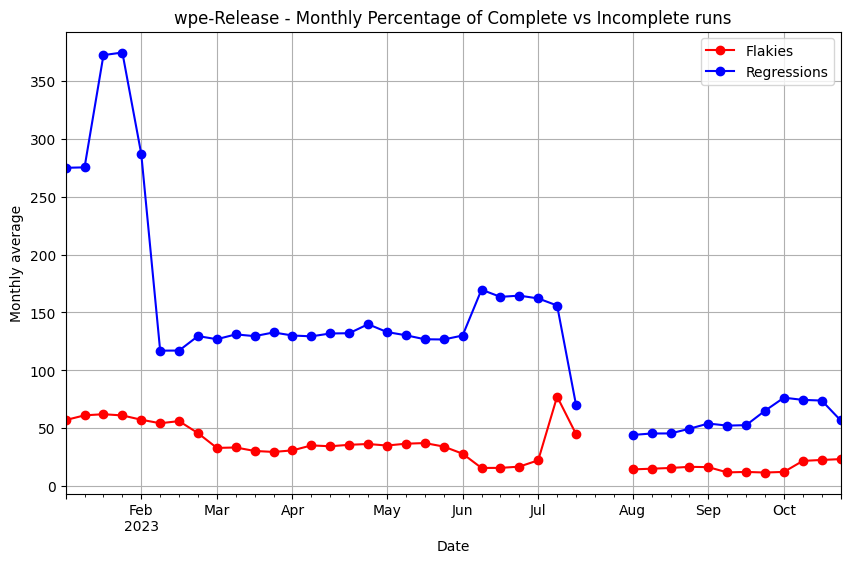

In [149]:
chart_regressions_flakies(wpe_release_df[~wpe_release_df["interrupted"]], "wpe-Release")

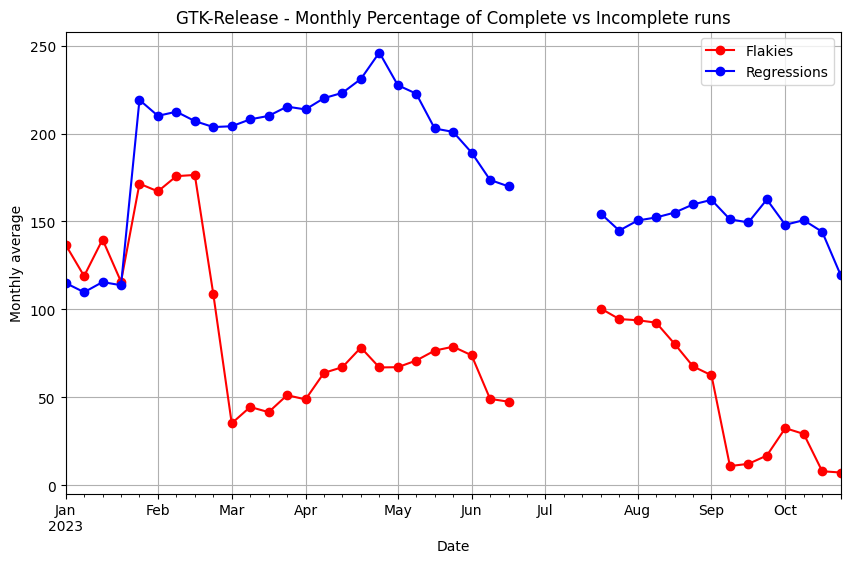

In [148]:
chart_regressions_flakies(gtk_release_df[~gtk_release_df["interrupted"]], "GTK-Release")

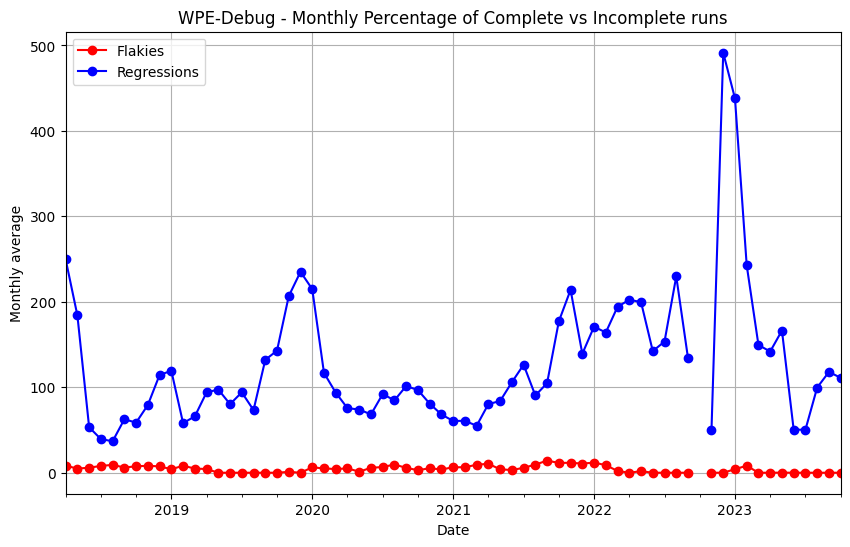

In [131]:
chart_regressions_flakies(wpe_debug_df, "WPE-Debug")

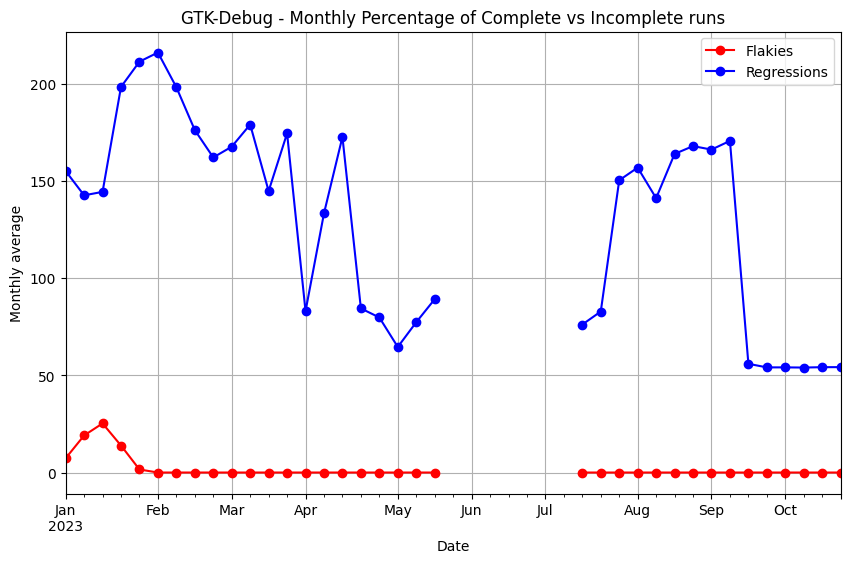

In [153]:
chart_regressions_flakies(gtk_debug_df, "GTK-Debug")

In [164]:
def chart_total(df, label):
    average_weekly_totals = df['num_total'].resample('W').mean()
    print(average_weekly_totals)
    plt.figure(figsize=(10, 6))
    average_weekly_totals.plot(marker='o', linestyle='-', color='r', label='Total tests run')
    plt.xlabel('Date')
    plt.ylabel('Weekly average')
    plt.title(f'{label} - Weekly average of total tests run')
    plt.legend()
    plt.grid(True)

In [168]:
gtk_release_df['skipped'].resample('W').mean()

date
2023-01-01    14015.000000
2023-01-08    14070.934426
2023-01-15    14102.750000
2023-01-22    14023.500000
2023-01-29    12638.162791
2023-02-05    12642.448276
2023-02-12    12551.818182
2023-02-19    12569.722222
2023-02-26    12400.767857
2023-03-05    13279.885246
2023-03-12    12394.285714
2023-03-19    12398.687500
2023-03-26    12396.188679
2023-04-02    12373.032787
2023-04-09    12239.566038
2023-04-16    12228.982143
2023-04-23    13790.220339
2023-04-30    12239.160714
2023-05-07    12243.625000
2023-05-14    12224.618182
2023-05-21    14621.500000
2023-05-28    12267.420000
2023-06-04    12274.108696
2023-06-11    12275.104167
2023-06-18    12299.553571
2023-06-25    12328.883333
2023-07-02    13504.854839
2023-07-09    12481.032787
2023-07-16    14437.058824
2023-07-23    12634.321429
2023-07-30    12514.180000
2023-08-06    12527.400000
2023-08-13    12644.648148
2023-08-20    13556.759259
2023-08-27    13518.333333
2023-09-03    12698.090909
2023-09-10    16433.440

date
2023-01-08    55904.000000
2023-01-15    56017.719101
2023-01-22    57492.671429
2023-01-29    58559.666667
2023-02-05    59360.724138
2023-02-12    59870.270833
2023-02-19    59869.086957
2023-02-26    59915.553191
2023-03-05    60000.193548
2023-03-12    60070.697674
2023-03-19    60141.141414
2023-03-26    60266.268041
2023-04-02    60369.643564
2023-04-09    60546.360465
2023-04-16    60684.659341
2023-04-23    60706.021277
2023-04-30    60725.486111
2023-05-07    60754.344828
2023-05-14    60842.857143
2023-05-21    60986.575758
2023-05-28    61422.173913
2023-06-04    61529.726027
2023-06-11    61553.178571
2023-06-18    61623.595960
2023-06-25    61670.819277
2023-07-02    61766.800000
2023-07-09    61815.325000
2023-07-16    61710.557143
2023-07-23             NaN
2023-07-30             NaN
2023-08-06    61707.824561
2023-08-13    61832.418605
2023-08-20    61978.910112
2023-08-27    61967.824742
2023-09-03    62093.727273
2023-09-10    62207.166667
2023-09-17    62299.234

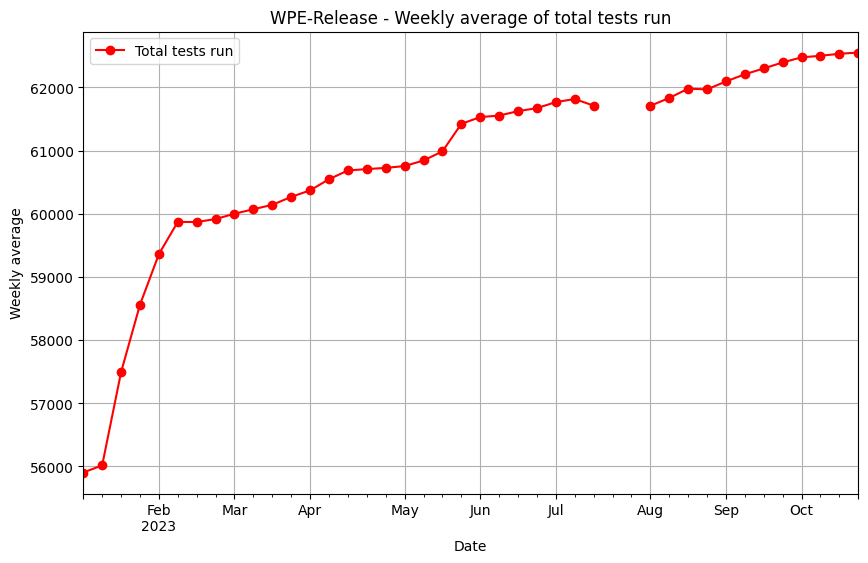

In [167]:
chart_total(wpe_release_df[~wpe_release_df["interrupted"]], "WPE-Release")

date
2023-01-01    62503.500000
2023-01-08    62526.131148
2023-01-15    62690.953125
2023-01-22    62884.375000
2023-01-29    65805.615385
2023-02-05    66004.614035
2023-02-12    66358.900000
2023-02-19    66607.264151
2023-02-26    66596.982143
2023-03-05    66626.250000
2023-03-12    66663.244898
2023-03-19    66767.609375
2023-03-26    66881.566038
2023-04-02    67025.131148
2023-04-09    67221.018868
2023-04-16    67349.517857
2023-04-23    67355.107143
2023-04-30    67398.446429
2023-05-07    67444.089286
2023-05-14    67541.381818
2023-05-21    67720.756757
2023-05-28    68121.714286
2023-06-04    68250.869565
2023-06-11    68341.354167
2023-06-18    68421.676471
2023-06-25             NaN
2023-07-02             NaN
2023-07-09             NaN
2023-07-16             NaN
2023-07-23    68479.500000
2023-07-30    68498.080000
2023-08-06    68538.818182
2023-08-13    68685.277778
2023-08-20    68832.396226
2023-08-27    68826.642857
2023-09-03    68960.690909
2023-09-10    68999.854

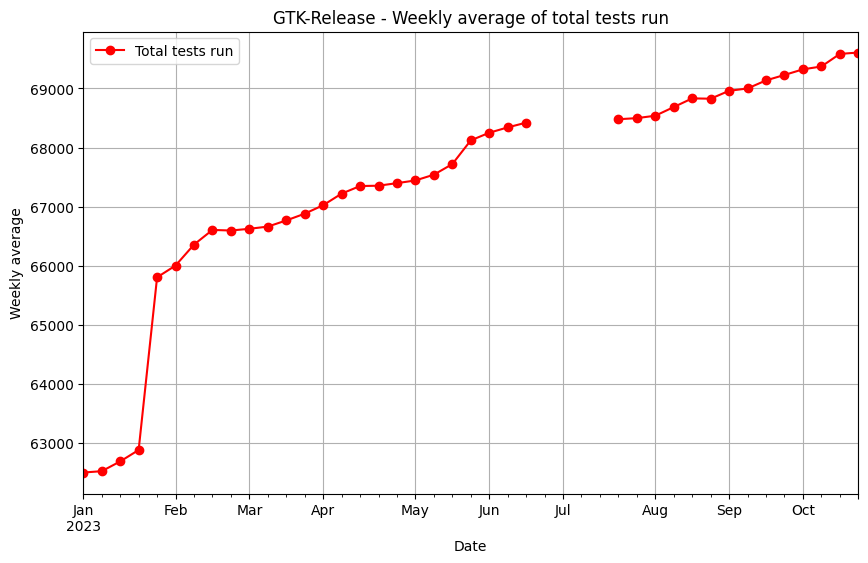

In [169]:
chart_total(gtk_release_df[~gtk_release_df["interrupted"]], "GTK-Release")